# scVI — Single-Cell Variational Inference
### TensorFlow 2 Implementation · Google Colab A100
**Paper:** Lopez et al., *Nature Methods* 2018  
**Goal:** Reproduce synthetic gene expression generation on the CORTEX dataset

---
**Workflow**
1. Mount Google Drive and install dependencies
2. Download / cache CORTEX dataset (one-time)
3. Train scVI model (400 epochs, KL warm-up, Adam ε=0.01)
4. Evaluate with paper-exact metrics (imputation median-L1, ARI, NMI, silhouette)
5. Generate synthetic cells and compare distributions


## 1 · Mount Drive & Install Dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn matplotlib seaborn umap-learn
print('✓  Dependencies ready')

Mounted at /content/drive
✓  Dependencies ready


## 2 · Imports

In [3]:
import os, csv, time, warnings, urllib.request
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.use('Agg')   # non-interactive backend (works in Colab too)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster  import KMeans
from sklearn.metrics  import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics  import silhouette_score as sk_silhouette
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

print(f'TensorFlow  : {tf.__version__}')
print(f'GPUs found  : {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.20.0
GPUs found  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3 · Configuration

In [13]:
# ── Paths ───────────────────────────────────────────────────────────────────
DATA_DIR    = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/OG_scVI_data'
EXP_DIR    = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scVI Approach'
RESULTS_DIR = os.path.join(EXP_DIR, 'results')
CKPT_DIR    = os.path.join(EXP_DIR, 'checkpoints')

for _d in [DATA_DIR, RESULTS_DIR, CKPT_DIR]:
    Path(_d).mkdir(parents=True, exist_ok=True)

# ── Hyperparameters (paper defaults) ─────────────────────────────────────────
CFG = dict(
    # Architecture
    n_latent        = 10,       # dim(z) — paper §Methods
    n_hidden        = 128,      # nodes per hidden layer
    n_layers        = 1,        # hidden layers
    dropout_rate    = 0.1,
    dispersion      = 'gene',   # per-gene θ_g

    # Training
    batch_size      = 128,      # M=128 — explicitly stated in paper
    n_epochs        = 400,
    lr_init         = .0004,
    adam_eps        = 0.01,     # ε=0.01 — explicitly stated in paper
    kl_warmup_frac  = 0.2,      # deterministic KL warm-up — paper
    val_split       = 0.1,
    lr_patience     = 25,
    lr_factor       = 0.5,
    lr_min          = 1e-6,

    # Checkpointing
    save_every      = 50,

    # Evaluation
    corrupt_rate    = 0.1,      # 10% synthetic dropout
    n_clusters      = 7,        # CORTEX: 7 cell types
    kmeans_inits    = 200,      # T=200 — paper
    n_mc_samples    = 25,

    # Generation
    n_synthetic     = 1000,

    seed            = 42,
)

EPS = 1e-8
np.random.seed(CFG['seed'])
tf.random.set_seed(CFG['seed'])
print('✓  Configuration set')

✓  Configuration set


## 4 · CORTEX Dataset
Downloads the [Zeisel et al. 2015](http://science.sciencemag.org/content/347/6226/1138) mouse cortex dataset once,
caches it as `cortex_558g.npz`, and loads from cache on every subsequent run.
- **3,005 cells × 558 genes** (top by variance, matching paper)
- **7 annotated cell types**


In [5]:
!pip install -q scvi-tools

import scvi
import anndata

_CORTEX_NPZ = "cortex_558g.npz"

def load_cortex(data_dir=DATA_DIR, n_top_genes=558):
    npz_path = os.path.join(data_dir, _CORTEX_NPZ)

    if os.path.exists(npz_path):
        print(f"[DATA] ✓  Cached CORTEX found  →  {npz_path}")
        d = np.load(npz_path, allow_pickle=True)
        return (d['X'].astype(np.float32),
                d['labels'].astype(np.int32),
                d['gene_names'].tolist(),
                d['cell_types'].tolist())

    print("[DATA]  Downloading CORTEX via scvi-tools (one-time)…")
    adata = scvi.data.cortex()   # ← the only change

    X_all = np.array(adata.X.todense() if hasattr(adata.X, 'todense') else adata.X, dtype=np.float32)
    cell_types_arr, labels_arr = np.unique(adata.obs['cell_type'].values, return_inverse=True)
    gene_names_arr = np.array(adata.var_names.tolist())

    top_idx = X_all.std(axis=0).argsort()[::-1][:n_top_genes]
    X_filt  = X_all[:, top_idx]
    gnames  = gene_names_arr[top_idx]

    print(f"[DATA] ✓  {X_filt.shape[0]} cells × {X_filt.shape[1]} genes | {len(cell_types_arr)} cell types")
    print(f"[DATA]    Cell types: {cell_types_arr.tolist()}")

    np.savez(npz_path, X=X_filt, labels=labels_arr,
             gene_names=gnames, cell_types=cell_types_arr)
    print(f"[DATA] ✓  Cached  →  {npz_path}\n")

    return (X_filt.astype(np.float32), labels_arr.astype(np.int32),
            gnames.tolist(), cell_types_arr.tolist())

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.1/699.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 60.5 MB/s eta 0:00:00


In [6]:
import scvi
import numpy as np
import os

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR    = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/OG_scVI_data'
_CORTEX_NPZ = 'cortex_558g.npz'
n_top_genes = 558

os.makedirs(DATA_DIR, exist_ok=True)

# ── Download ──────────────────────────────────────────────────────────────────
print("Downloading CORTEX via scvi-tools…")
adata = scvi.data.cortex()

# ── Extract ───────────────────────────────────────────────────────────────────
X_all = np.array(adata.X.todense() if hasattr(adata.X, 'todense') else adata.X, dtype=np.float32)
cell_types_arr, labels_arr = np.unique(adata.obs['cell_type'].values, return_inverse=True)
gene_names_arr = np.array(adata.var_names.tolist())

# ── Top 558 genes by variance (paper-exact) ───────────────────────────────────
top_idx = X_all.std(axis=0).argsort()[::-1][:n_top_genes]
X_filt  = X_all[:, top_idx]
gnames  = gene_names_arr[top_idx]

# ── Save to Drive ─────────────────────────────────────────────────────────────
npz_path = os.path.join(DATA_DIR, _CORTEX_NPZ)
np.savez(npz_path, X=X_filt, labels=labels_arr,
         gene_names=gnames, cell_types=cell_types_arr)

print(f"✓  Saved  →  {npz_path}")
print(f"   Shape  : {X_filt.shape[0]} cells × {X_filt.shape[1]} genes")
print(f"   Labels : {cell_types_arr.tolist()}")

INFO     Downloading file at /content/data/expression.bin                                                          


Downloading...:   0%|          | 0/121129.0 [00:00<?, ?it/s]

INFO     Loading Cortex data from /content/data/expression.bin                                                     
INFO     Finished loading Cortex data                                                                              
✓  Saved  →  /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/OG_scVI_data/cortex_558g.npz
   Shape  : 3005 cells × 558 genes
   Labels : ['astrocytes_ependymal', 'endothelial-mural', 'interneurons', 'microglia', 'oligodendrocytes', 'pyramidal CA1', 'pyramidal SS']


In [9]:
EPS = 1e-8
_CORTEX_NPZ = "cortex_558g.npz"

def compute_library_prior(X, batch_ids=None):
    if batch_ids is None:
        batch_ids = np.zeros(len(X), dtype=np.int32)
    log_lib = np.log(X.sum(axis=1) + EPS)
    l_mean = np.zeros(len(X), dtype=np.float32)
    l_var  = np.zeros(len(X), dtype=np.float32)
    for b in np.unique(batch_ids):
        mask = (batch_ids == b)
        l_mean[mask] = log_lib[mask].mean()
        l_var[mask]  = log_lib[mask].var() + EPS
    return l_mean, l_var

def load_cortex(data_dir=DATA_DIR, n_top_genes=558):
    npz_path = os.path.join(data_dir, _CORTEX_NPZ)
    print(f"[DATA] ✓  Loading from cache  →  {npz_path}")
    d = np.load(npz_path, allow_pickle=True)
    return (d['X'].astype(np.float32),
            d['labels'].astype(np.int32),
            d['gene_names'].tolist(),
            d['cell_types'].tolist())

X, labels, gene_names, cell_types = load_cortex(DATA_DIR)
l_mean, l_var = compute_library_prior(X)
n_cells, n_genes = X.shape

print(f"Dataset  : {n_cells} cells × {n_genes} genes")
print(f"Classes  : {cell_types}")

[DATA] ✓  Loading from cache  →  /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/OG_scVI_data/cortex_558g.npz
Dataset  : 3005 cells × 558 genes
Classes  : ['astrocytes_ependymal', 'endothelial-mural', 'interneurons', 'microglia', 'oligodendrocytes', 'pyramidal CA1', 'pyramidal SS']


## 5 · Distributions: ZINB Log-Likelihood & KL
Exact TensorFlow port of scVI's `log_zinb_positive()` from `log_likelihood.py`.


In [5]:
def log_zinb_positive(x, mu, theta, pi):
    """
    Per-gene-per-cell ZINB log-likelihood.
    Exact TF port of scVI log_zinb_positive() (log_likelihood.py).
    """
    if len(theta.shape) == 1:
        theta = tf.expand_dims(theta, 0)        # (1,G) for broadcasting
    softplus_pi      = tf.nn.softplus(-pi)
    log_theta_eps    = tf.math.log(theta + EPS)
    log_theta_mu_eps = tf.math.log(theta + mu + EPS)
    pi_theta_log     = -pi + theta * (log_theta_eps - log_theta_mu_eps)
    case_zero     = tf.nn.softplus(pi_theta_log) - softplus_pi
    case_non_zero = (
        -softplus_pi + pi_theta_log
        + x * (tf.math.log(mu + EPS) - log_theta_mu_eps)
        + tf.math.lgamma(x + theta)
        - tf.math.lgamma(theta)
        - tf.math.lgamma(x + 1.0)
    )
    mask = tf.cast(x < EPS, tf.float32)
    return mask * case_zero + (1.0 - mask) * case_non_zero

def kl_normal(q_m, q_v, p_m=None, p_v=None):
    """KL(N(q_m,q_v) || N(p_m,p_v)) summed over last dim."""
    if p_m is None: p_m = tf.zeros_like(q_m)
    if p_v is None: p_v = tf.ones_like(q_v)
    return 0.5 * tf.reduce_sum(
        tf.math.log(p_v + EPS) - tf.math.log(q_v + EPS)
        + (q_v + (q_m - p_m)**2) / (p_v + EPS) - 1.0,
        axis=-1
    )

print('✓  Distributions defined')

✓  Distributions defined


## 6 · Neural Network Modules
- **FCBlock**: Linear → BatchNorm (momentum=0.99 ≡ PyTorch 0.01) → ReLU → Dropout
- **Encoder**: FCBlock(s) → mean head + var head, reparameterisation trick
- **DecoderSCVI**: FCBlock(s) → softmax(scale) + dropout logits; μ = exp(ℓ)·ρ


In [6]:
class FCBlock(keras.layers.Layer):
    """FC → BN (momentum=0.99, eps=0.001) → ReLU → Dropout"""
    def __init__(self, n_out, dropout_rate=0.1, use_bn=True, **kw):
        super().__init__(**kw)
        self.dense = keras.layers.Dense(n_out, use_bias=True)
        self.bn    = (keras.layers.BatchNormalization(momentum=0.99, epsilon=0.001)
                      if use_bn else None)
        self.relu  = keras.layers.ReLU()
        self.drop  = keras.layers.Dropout(dropout_rate) if dropout_rate > 0 else None
    def call(self, x, training=False):
        x = self.dense(x)
        if self.bn:   x = self.bn(x, training=training)
        x = self.relu(x)
        if self.drop: x = self.drop(x, training=training)
        return x


class Encoder(keras.layers.Layer):
    """x_log → (q_mean, q_var, sample) via reparameterisation."""
    def __init__(self, n_input, n_output, n_hidden=128, n_layers=1, dropout_rate=0.1, **kw):
        super().__init__(**kw)
        self.fc     = [FCBlock(n_hidden, dropout_rate, name=f'fc{i}') for i in range(n_layers)]
        self.mean_h = keras.layers.Dense(n_output, name='mean_head')
        self.var_h  = keras.layers.Dense(n_output, name='var_head')
    def call(self, x, training=False):
        h = x
        for fc in self.fc: h = fc(h, training=training)
        q_m = self.mean_h(h)
        q_v = tf.exp(self.var_h(h)) + 1e-4
        eps = tf.random.normal(tf.shape(q_m))
        z   = q_m + tf.sqrt(q_v) * eps
        return q_m, q_v, z


class DecoderSCVI(keras.layers.Layer):
    """z, library → (px_scale ρ, px_rate μ, px_dropout logits)"""
    def __init__(self, n_latent, n_output, n_hidden=128, n_layers=1, **kw):
        super().__init__(**kw)
        self.fc      = [FCBlock(n_hidden, dropout_rate=0.0, name=f'fc{i}') for i in range(n_layers)]
        self.scale_h = keras.layers.Dense(n_output, name='scale_head')
        self.drop_h  = keras.layers.Dense(n_output, name='dropout_head')
    def call(self, z, library, training=False):
        h = z
        for fc in self.fc: h = fc(h, training=training)
        px_scale   = tf.nn.softmax(self.scale_h(h), axis=-1)
        px_dropout = self.drop_h(h)
        px_rate    = tf.exp(library) * px_scale
        return px_scale, px_rate, px_dropout

print('✓  NN modules defined')

✓  NN modules defined


## 7 · scVI Model
Full ELBO: `recon_loss + KL(q(ℓ)||p(ℓ)) + kl_weight · KL(q(z)||p(z))`


In [7]:
class scVI(keras.Model):
    """
    Lopez et al. (2018) scVI model.
    Generative:  z ~ N(0,I), ℓ ~ LogNormal(prior), x ~ ZINB(ℓ·ρ, θ, h)
    Variational: q(z|x) = N(μ_z, σ²_z), q(ℓ|x) = N(μ_ℓ, σ²_ℓ)
    """
    def __init__(self, n_input, n_hidden=128, n_latent=10, n_layers=1,
                 dropout_rate=0.1, dispersion='gene', **kw):
        super().__init__(**kw)
        self.n_latent   = n_latent
        self.n_input    = n_input
        self.dispersion = dispersion
        # Trainable per-gene log-dispersion
        self.log_theta  = tf.Variable(tf.random.normal([n_input]), trainable=True, name='log_theta')
        # KL warm-up weight (not trained by optimiser)
        self.kl_weight  = tf.Variable(0.0, trainable=False, dtype=tf.float32, name='kl_weight')
        # Encoders
        self.z_encoder  = Encoder(n_input, n_latent, n_hidden, n_layers, dropout_rate, name='z_encoder')
        self.l_encoder  = Encoder(n_input, 1,        n_hidden, 1,         dropout_rate, name='l_encoder')
        # Decoder
        self.decoder    = DecoderSCVI(n_latent, n_input, n_hidden, n_layers, name='decoder')

    def _encode(self, x, training=False):
        x_log = tf.math.log1p(x)
        qz_m, qz_v, z       = self.z_encoder(x_log, training=training)
        ql_m, ql_v, library = self.l_encoder(x_log, training=training)
        return qz_m, qz_v, z, ql_m, ql_v, library

    def _decode(self, z, library, training=False):
        px_scale, px_rate, px_dropout = self.decoder(z, library, training=training)
        theta = tf.exp(self.log_theta)
        return px_scale, px_rate, px_dropout, theta

    def compute_elbo(self, x, local_l_mean, local_l_var, training=False):
        qz_m, qz_v, z, ql_m, ql_v, library = self._encode(x, training=training)
        _, px_rate, px_dropout, theta        = self._decode(z, library, training=training)
        recon = -tf.reduce_sum(log_zinb_positive(x, px_rate, theta, px_dropout), axis=-1)
        kl_z  = kl_normal(qz_m, qz_v)
        kl_l  = kl_normal(ql_m, ql_v, local_l_mean, local_l_var)
        loss  = tf.reduce_mean(recon + kl_l) + self.kl_weight * tf.reduce_mean(kl_z)
        return loss, tf.reduce_mean(recon), tf.reduce_mean(kl_z), tf.reduce_mean(kl_l)

    def get_latent(self, X_np, batch_size=512):
        out = []
        for i in range(0, len(X_np), batch_size):
            xb = tf.constant(X_np[i:i+batch_size], dtype=tf.float32)
            qz_m, _, _ = self.z_encoder(tf.math.log1p(xb), training=False)
            out.append(qz_m.numpy())
        return np.concatenate(out, axis=0)

    def get_imputed(self, X_np, batch_size=512):
        out = []
        for i in range(0, len(X_np), batch_size):
            xb = tf.constant(X_np[i:i+batch_size], dtype=tf.float32)
            _, _, z, _, _, lib = self._encode(xb, training=False)
            _, px_rate, _, _   = self._decode(z, lib, training=False)
            out.append(px_rate.numpy())
        return np.concatenate(out, axis=0)

    def generate(self, n_samples=1000, l_mean_prior=None, l_std_prior=None):
        z = tf.random.normal([n_samples, self.n_latent])
        if l_mean_prior is None: l_mean_prior = 7.0
        if l_std_prior  is None: l_std_prior  = 0.5
        library = tf.random.normal([n_samples, 1]) * l_std_prior + l_mean_prior
        _, px_rate, px_dropout, theta = self._decode(z, library, training=False)
        mu_np    = px_rate.numpy()
        theta_np = theta.numpy()
        pi_np    = px_dropout.numpy()
        theta_bc = np.broadcast_to(theta_np, mu_np.shape)
        lam      = np.random.gamma(shape=theta_bc, scale=mu_np/(theta_bc+EPS))
        lam      = np.clip(lam, 0, 1e8)
        counts   = np.random.poisson(lam).astype(np.float32)
        drop_p   = 1.0 / (1.0 + np.exp(-pi_np))
        counts[np.random.uniform(size=pi_np.shape) < drop_p] = 0.0
        return {'counts': counts, 'px_scale': None, 'px_rate': mu_np, 'px_dropout': pi_np}

print('✓  scVI model class defined')

✓  scVI model class defined


## 8 · Instantiate & Inspect Model

In [10]:
model = scVI(
    n_input      = n_genes,
    n_hidden     = CFG['n_hidden'],
    n_latent     = CFG['n_latent'],
    n_layers     = CFG['n_layers'],
    dropout_rate = CFG['dropout_rate'],
    dispersion   = CFG['dispersion'],
    name         = 'scVI_CORTEX',
)
# Build weights via dummy forward pass
_ = model.compute_elbo(
    tf.zeros([2, n_genes], dtype=tf.float32),
    tf.zeros([2, 1],       dtype=tf.float32),
    tf.ones( [2, 1],       dtype=tf.float32),
)
model.summary()

Model: "scVI_CORTEX"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_encoder (Encoder)             │ ?                      │        74,644 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l_encoder (Encoder)             │ ?                      │        72,322 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (DecoderSCVI)           │ ?                      │       145,884 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,850 (1.12 MB)

 Trainable params: 292,082 (1.11 MB)

 Non-trainable params: 768 (3.00 KB)

## 9 · Build Data Pipelines

In [11]:
def make_datasets(X, l_mean, l_var, labels, batch_size=128, val_split=0.1, seed=42):
    n   = len(X)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_val     = max(1, int(n * val_split))
    val_idx   = idx[:n_val]
    train_idx = idx[n_val:]

    def _ds(indices, shuffle):
        d = tf.data.Dataset.from_tensor_slices({
            'x':      X[indices].astype(np.float32),
            'l_mean': l_mean[indices].reshape(-1, 1).astype(np.float32),
            'l_var':  l_var[indices].reshape(-1, 1).astype(np.float32),
            'label':  labels[indices].astype(np.int32),
        })
        if shuffle:
            d = d.shuffle(len(indices), seed=seed, reshuffle_each_iteration=True)
        return d.batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

    return (_ds(train_idx, True), _ds(val_idx, False),
            train_idx, val_idx)

train_ds, val_ds, train_idx, val_idx = make_datasets(
    X, l_mean, l_var, labels,
    batch_size = CFG['batch_size'],
    val_split  = CFG['val_split'],
    seed       = CFG['seed'],
)
print(f'Train: {len(train_idx)} cells  |  Val: {len(val_idx)} cells')

Train: 2705 cells  |  Val: 300 cells


## 10 · Training
- **Adam** with ε=0.01 (paper-exact)
- **KL warm-up**: linear 0→1 over first 40% of epochs
- **ReduceLROnPlateau**: patience=25, factor=0.5
- Saves best weights + periodic checkpoint every 50 epochs


In [14]:
import json, time

def train(model, train_ds, val_ds, cfg, ckpt_dir, results_dir):

    # ── Build model ───────────────────────────────────────────────────────────
    _ = model.compute_elbo(
        tf.zeros([2, n_genes], dtype=tf.float32),
        tf.zeros([2, 1],       dtype=tf.float32),
        tf.ones( [2, 1],       dtype=tf.float32),
    )
    print('✓  Model built and ready')

    # ── Checkpoint object (no built-check restriction) ────────────────────────
    ckpt = tf.train.Checkpoint(model=model)

    # ── Optimizer ─────────────────────────────────────────────────────────────
    optimizer     = keras.optimizers.Adam(learning_rate=cfg['lr_init'], epsilon=cfg['adam_eps'])
    n_epochs      = cfg['n_epochs']
    warmup_epochs = max(1, int(n_epochs * cfg['kl_warmup_frac']))
    save_every    = cfg['save_every']
    current_lr    = cfg['lr_init']
    best_val      = np.inf
    best_epoch    = 0
    patience_cnt  = 0
    train_losses, val_losses, lr_hist = [], [], []

    @tf.function
    def train_step(x, l_mean, l_var):
        with tf.GradientTape() as tape:
            loss, _, _, _ = model.compute_elbo(x, l_mean, l_var, training=True)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    @tf.function
    def val_step(x, l_mean, l_var):
        loss, _, _, _ = model.compute_elbo(x, l_mean, l_var, training=False)
        return loss

    sep = '═' * 85
    print(f'\n{sep}')
    print(f'  scVI Training on CORTEX  |  {n_epochs} epochs  |  '
          f'batch {cfg["batch_size"]}  |  KL warm-up {warmup_epochs} epochs')
    print(sep)
    total_t0 = time.time()

    for epoch in range(1, n_epochs + 1):

        # ── KL warm-up ────────────────────────────────────────────────────────
        model.kl_weight.assign(float(min(1.0, epoch / warmup_epochs)))

        # ── Train ─────────────────────────────────────────────────────────────
        t_sum, t_n = 0.0, 0
        for batch in train_ds:
            t_sum += float(train_step(batch['x'], batch['l_mean'], batch['l_var']))
            t_n   += 1
        t_loss = t_sum / t_n

        # ── Validate ──────────────────────────────────────────────────────────
        v_sum, v_n = 0.0, 0
        for batch in val_ds:
            v_sum += float(val_step(batch['x'], batch['l_mean'], batch['l_var']))
            v_n   += 1
        v_loss = v_sum / v_n

        train_losses.append(t_loss)
        val_losses.append(v_loss)
        lr_hist.append(current_lr)

        # ── Best model ────────────────────────────────────────────────────────
        if v_loss < best_val:
            best_val     = v_loss
            best_epoch   = epoch
            ckpt.write(os.path.join(ckpt_dir, 'best_model'))
            patience_cnt = 0
        else:
            patience_cnt += 1

        # ── ReduceLROnPlateau ─────────────────────────────────────────────────
        if patience_cnt > 0 and patience_cnt % cfg['lr_patience'] == 0:
            new_lr = max(current_lr * cfg['lr_factor'], cfg['lr_min'])
            if new_lr < current_lr:
                current_lr = new_lr
                optimizer.learning_rate.assign(current_lr)

        # ── Periodic checkpoint ───────────────────────────────────────────────
        if epoch % save_every == 0:
            ckpt.write(os.path.join(ckpt_dir, f'epoch_{epoch:04d}'))

        # ── Progress line ─────────────────────────────────────────────────────
        elapsed_m = (time.time() - total_t0) / 60.0
        end_char  = '\n' if (epoch % 10 == 0 or epoch == n_epochs) else '\r'
        print(
            f'Epoch {epoch:4d}/{n_epochs} | '
            f'Train ELBO: {t_loss:10.4f} | '
            f'Val ELBO: {v_loss:10.4f} | '
            f'LR: {current_lr:.2e} | '
            f'{elapsed_m:6.1f}m | '
            f'Best: {best_val:.4f}@{best_epoch}',
            end=end_char, flush=True,
        )

    print()
    print(sep)
    print(f'  Training complete  |  Best Val ELBO: {best_val:.4f}  @ epoch {best_epoch}')
    print(sep)

    # ── Save history as JSON (survives disconnection) ─────────────────────────
    history = {
        'train'      : train_losses,
        'val'        : val_losses,
        'lr'         : lr_hist,
        'best_val'   : best_val,
        'best_epoch' : best_epoch,
    }
    json_path = os.path.join(results_dir, 'history.json')
    with open(json_path, 'w') as f:
        json.dump(history, f)
    print(f'  [SAVED] History  →  {json_path}')

    return history


# ── TRAIN ─────────────────────────────────────────────────────────────────────
history = train(model, train_ds, val_ds, CFG, CKPT_DIR, RESULTS_DIR)

✓  Model built and ready

═════════════════════════════════════════════════════════════════════════════════════
  scVI Training on CORTEX  |  400 epochs  |  batch 128  |  KL warm-up 80 epochs
═════════════════════════════════════════════════════════════════════════════════════
Epoch   10/400 | Train ELBO:  4679.5473 | Val ELBO:  5543.7918 | LR: 4.00e-04 |    0.1m | Best: 3936.6259@4
Epoch   20/400 | Train ELBO:  1771.5144 | Val ELBO:  1893.6578 | LR: 4.00e-04 |    0.2m | Best: 1893.6578@20
Epoch   30/400 | Train ELBO:  1567.9231 | Val ELBO:  1485.5246 | LR: 4.00e-04 |    0.2m | Best: 1484.8612@29
Epoch   40/400 | Train ELBO:  1581.0567 | Val ELBO:  1479.7578 | LR: 4.00e-04 |    0.2m | Best: 1469.5074@37
Epoch   50/400 | Train ELBO:  1516.0393 | Val ELBO:  1465.8024 | LR: 4.00e-04 |    0.3m | Best: 1463.9671@49
Epoch   60/400 | Train ELBO:  1541.6550 | Val ELBO:  1448.5915 | LR: 4.00e-04 |    0.3m | Best: 1442.2804@54
Epoch   70/400 | Train ELBO:  1522.7980 | Val ELBO:  1460.7743 | LR: 

## 11 · Loss Curves (Train vs. Val)

In [15]:
def plot_losses(history, results_dir):
    epochs = np.arange(1, len(history['train']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('scVI Training — CORTEX Dataset', fontsize=14, fontweight='bold')
    ax = axes[0]
    ax.plot(epochs, history['train'], lw=1.5, color='#1f77b4', label='Train ELBO', alpha=0.9)
    ax.plot(epochs, history['val'],   lw=1.5, color='#ff7f0e', label='Val ELBO',   alpha=0.9)
    ax.axvline(history['best_epoch'], color='gray', ls='--', lw=1, alpha=0.7,
               label=f'Best @ {history["best_epoch"]}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('ELBO Loss per cell')
    ax.set_title('Train vs. Validation ELBO'); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1]
    ax.plot(epochs, history['lr'], lw=1.5, color='#2ca02c')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule'); ax.set_yscale('log'); ax.grid(alpha=0.3)
    plt.tight_layout()
    save_path = os.path.join(results_dir, 'loss_curves.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[PLOT] Loss curves  →  {save_path}')

# Load best weights before evaluation
best_ckpt = os.path.join(CKPT_DIR, 'best_model')
ckpt = tf.train.Checkpoint(model=model)
ckpt.restore(best_ckpt).expect_partial()
print(f'[CKPT] Best weights loaded  ← {best_ckpt}')

plot_losses(history, RESULTS_DIR)

[CKPT] Best weights loaded  ← /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scVI Approach/checkpoints/best_model
[PLOT] Loss curves  →  /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scVI Approach/results/loss_curves.png


If the connection is lost,

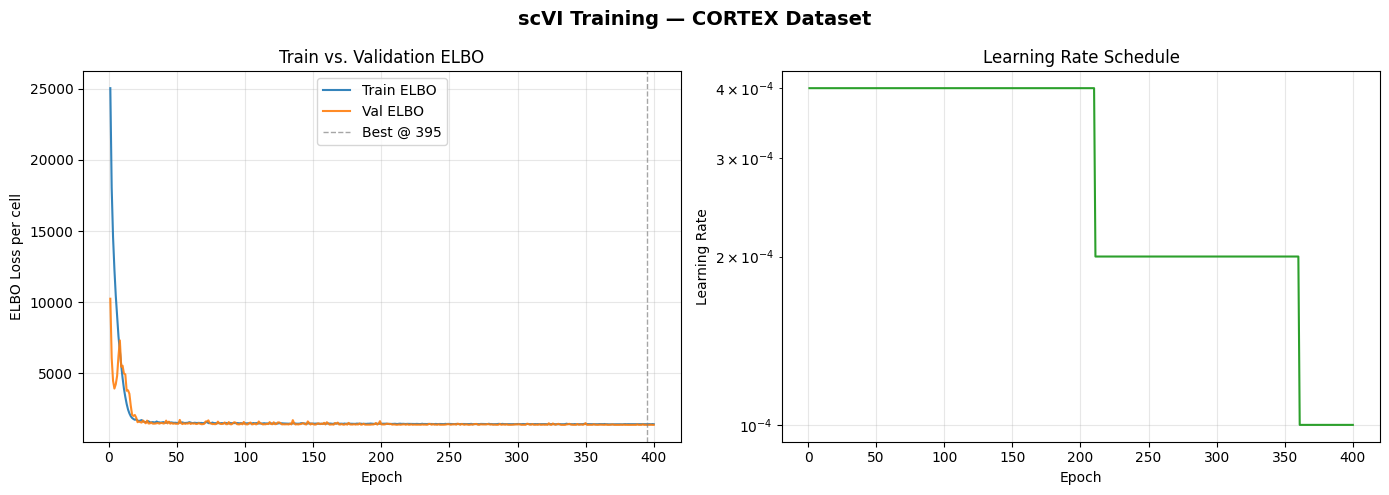

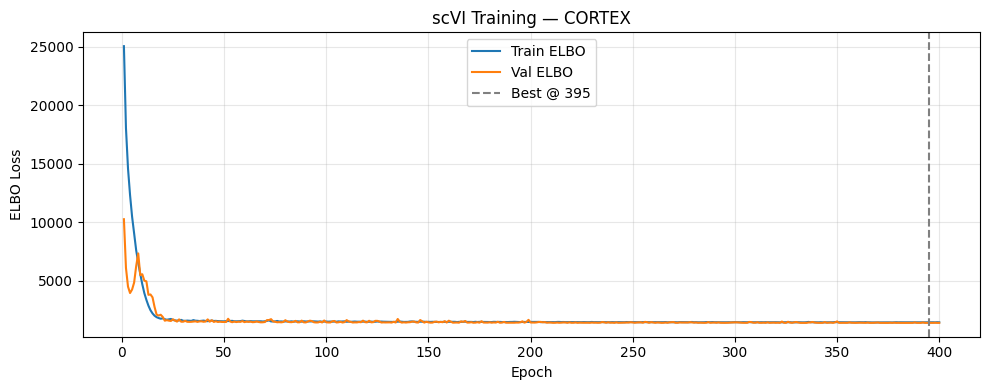

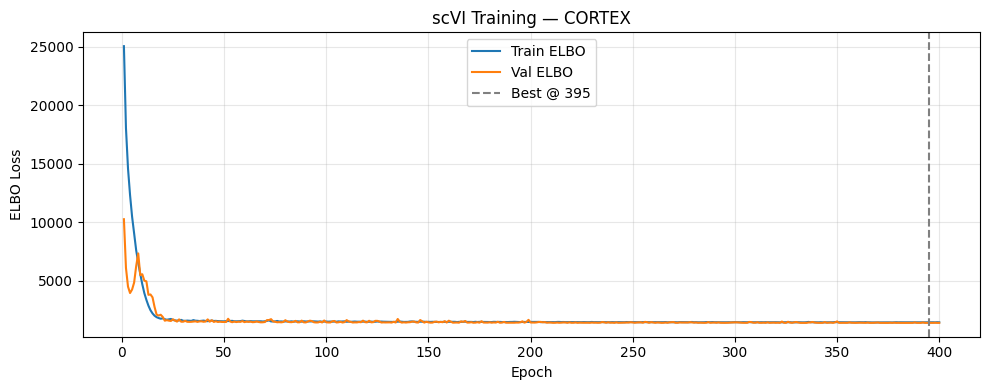

Best Val ELBO: 1384.3747 @ epoch 395


In [18]:
import matplotlib
matplotlib.use('inline')   # override Agg for Colab display

with open('/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scVI Approach/results/history.json') as f:
    history = json.load(f)

epochs = np.arange(1, len(history['train']) + 1)
plt.figure(figsize=(10, 4))
plt.plot(epochs, history['train'], label='Train ELBO')
plt.plot(epochs, history['val'],   label='Val ELBO')
plt.axvline(history['best_epoch'], color='gray', ls='--', label=f"Best @ {history['best_epoch']}")
plt.xlabel('Epoch'); plt.ylabel('ELBO Loss')
plt.title('scVI Training — CORTEX')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()
print(f"Best Val ELBO: {history['best_val']:.4f} @ epoch {history['best_epoch']}")

## 12 · Paper-Exact Evaluation Metrics (Model Quality)
| Metric | How computed |
|---|---|
| **Imputation Median L1** | Synthetic 10% dropout → impute via NB mean → median\|x_orig − x_imp\| |
| **Clustering ARI** | k-means (k=7, T=200 inits) on latent space |
| **Clustering NMI** | Normalised mutual information |
| **Silhouette** | s(i) = (b−a)/max(a,b) on latent space |


In [16]:
def corrupt_uniform(X, rate=0.1, seed=42):
    rng = np.random.default_rng(seed)
    X_c = X.copy()
    nz_r, nz_c = np.where(X > 0)
    n_corr = int(len(nz_r) * rate)
    chosen = rng.choice(len(nz_r), size=n_corr, replace=False)
    ci, cj = nz_r[chosen], nz_c[chosen]
    bern   = rng.binomial(1, 0.9, size=n_corr).astype(np.float32)
    X_c[ci, cj] = X[ci, cj] * bern
    mask = np.zeros_like(X, dtype=bool)
    mask[ci, cj] = True
    return X_c.astype(np.float32), mask

def eval_imputation(model, X_orig, X_corr, mask, n_mc=25):
    imp_acc = np.zeros_like(X_orig, dtype=np.float32)
    for _ in range(n_mc):
        imp_acc += model.get_imputed(X_corr)
    imputed = imp_acc / n_mc
    l1 = float(np.median(np.abs(X_orig[mask] - imputed[mask])))
    return l1, imputed

def eval_clustering(z, true_labels, n_clusters, n_inits=200, seed=42):
    km   = KMeans(n_clusters=n_clusters, n_init=n_inits, random_state=seed)
    pred = km.fit_predict(z)
    ari  = adjusted_rand_score(true_labels, pred)
    nmi  = normalized_mutual_info_score(true_labels, pred)
    return ari, nmi, pred

def eval_silhouette(z, labels, max_cells=5000):
    if len(np.unique(labels)) < 2: return 0.0
    if len(z) > max_cells:
        idx = np.random.choice(len(z), max_cells, replace=False)
        z, labels = z[idx], labels[idx]
    return float(sk_silhouette(z, labels))

bar = '─' * 60
print(f'\n{bar}\n  EVALUATION — paper-exact metrics\n{bar}')

print('  [1/4] Encoding → latent space…')
z = model.get_latent(X)

print('  [2/4] Imputation benchmark…')
X_c, mask = corrupt_uniform(X, CFG['corrupt_rate'], CFG['seed'])
l1, _     = eval_imputation(model, X, X_c, mask, CFG['n_mc_samples'])

print(f'  [3/4] k-means clustering (k={CFG["n_clusters"]}, T={CFG["kmeans_inits"]})…')
ari, nmi, pred_labels = eval_clustering(z, labels, CFG['n_clusters'], CFG['kmeans_inits'], CFG['seed'])

print('  [4/4] Silhouette score…')
sil = eval_silhouette(z, labels)

print(f'\n{bar}')
print(f'  Imputation Median L1  : {l1:.4f}   (lower = better)')
print(f'  Clustering ARI        : {ari:.4f}   (higher = better)')
print(f'  Clustering NMI        : {nmi:.4f}   (higher = better)')
print(f'  Silhouette score      : {sil:.4f}   (higher = better)')
print(bar)


────────────────────────────────────────────────────────────
  EVALUATION — paper-exact metrics
────────────────────────────────────────────────────────────
  [1/4] Encoding → latent space…
  [2/4] Imputation benchmark…
  [3/4] k-means clustering (k=7, T=200)…
  [4/4] Silhouette score…

────────────────────────────────────────────────────────────
  Imputation Median L1  : 2.6451   (lower = better)
  Clustering ARI        : 0.7398   (higher = better)
  Clustering NMI        : 0.7649   (higher = better)
  Silhouette score      : 0.2307   (higher = better)
────────────────────────────────────────────────────────────


## 13 · t-SNE Visualisation of Latent Space

[t-SNE] Computing embedding…


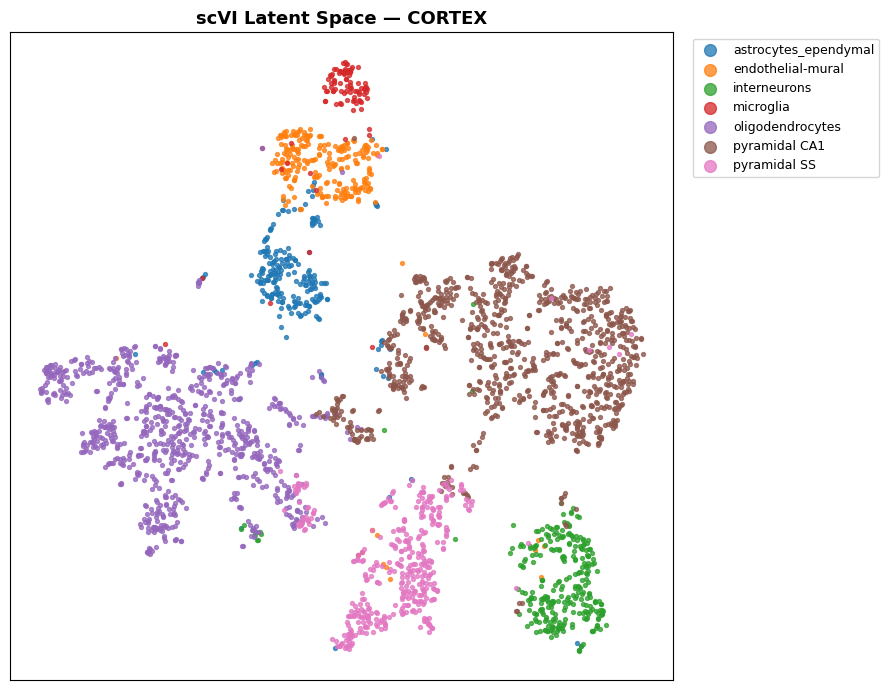

[PLOT] t-SNE  →  /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scVI Approach/results/tsne_latent.png


In [19]:
print('[t-SNE] Computing embedding…')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
z2d  = tsne.fit_transform(z)

palette = sns.color_palette('tab10', len(cell_types))
fig, ax = plt.subplots(figsize=(9, 7))
for i, ct in enumerate(cell_types):
    m = (labels == i)
    ax.scatter(z2d[m,0], z2d[m,1], c=[palette[i]], label=ct, s=8, alpha=0.75, rasterized=True)
ax.set_title('scVI Latent Space — CORTEX', fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=9, bbox_to_anchor=(1.02,1), loc='upper left')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'tsne_latent.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'[PLOT] t-SNE  →  {save_path}')

## 14 · Generate Synthetic Cells
Sample `z ~ N(0,I)`, `ℓ ~ LogNormal(prior)`, then `x ~ ZINB(ℓ·ρ, θ, h)` via Gamma-Poisson mixture.


Generating 1000 synthetic cells…
Shape        : (1000, 558)
Mean count   : 9.69
Sparsity     : 34.8%


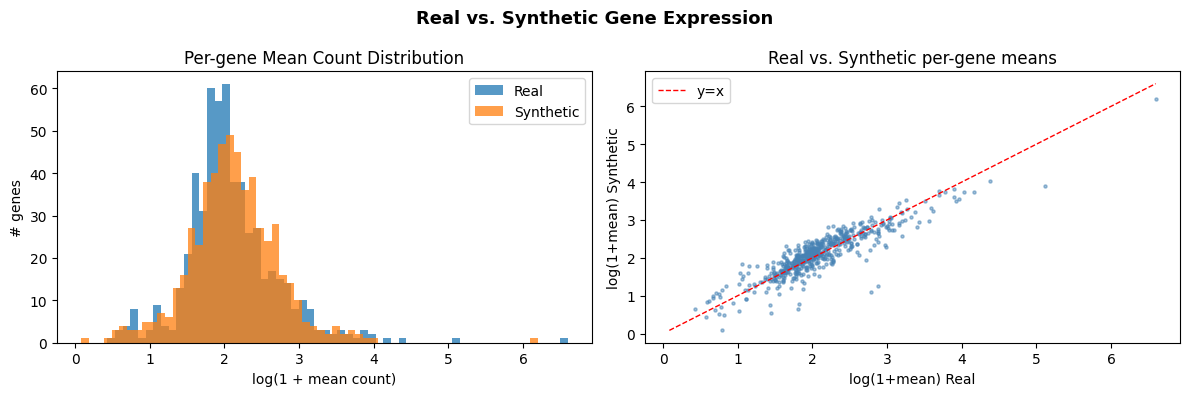

[PLOT] Real vs Synth  →  /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scVI Approach/results/real_vs_synthetic.png


In [20]:
log_lib  = np.log(X.sum(axis=1))
lib_mean = float(log_lib.mean())
lib_std  = float(log_lib.std())

print(f'Generating {CFG["n_synthetic"]} synthetic cells…')
gen = model.generate(CFG['n_synthetic'], l_mean_prior=lib_mean, l_std_prior=lib_std)
synth_counts = gen['counts']

np.save(os.path.join(RESULTS_DIR, 'synthetic_cells.npy'),    synth_counts)
np.save(os.path.join(RESULTS_DIR, 'synthetic_px_rate.npy'),  gen['px_rate'])

print(f'Shape        : {synth_counts.shape}')
print(f'Mean count   : {synth_counts.mean():.2f}')
print(f'Sparsity     : {(synth_counts==0).mean()*100:.1f}%')

# Compare distributions
gene_means_real  = X.mean(axis=0)
gene_means_synth = synth_counts.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Real vs. Synthetic Gene Expression', fontsize=13, fontweight='bold')
axes[0].hist(np.log1p(gene_means_real),  bins=60, color='#1f77b4', alpha=0.75, label='Real')
axes[0].hist(np.log1p(gene_means_synth), bins=60, color='#ff7f0e', alpha=0.75, label='Synthetic')
axes[0].set_xlabel('log(1 + mean count)'); axes[0].set_ylabel('# genes')
axes[0].set_title('Per-gene Mean Count Distribution'); axes[0].legend()
axes[1].scatter(np.log1p(gene_means_real), np.log1p(gene_means_synth), s=5, alpha=0.5, c='steelblue')
mn = min(np.log1p(gene_means_real).min(), np.log1p(gene_means_synth).min())
mx = max(np.log1p(gene_means_real).max(), np.log1p(gene_means_synth).max())
axes[1].plot([mn,mx],[mn,mx],'r--',lw=1,label='y=x')
axes[1].set_xlabel('log(1+mean) Real'); axes[1].set_ylabel('log(1+mean) Synthetic')
axes[1].set_title('Real vs. Synthetic per-gene means'); axes[1].legend()
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'real_vs_synthetic.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'[PLOT] Real vs Synth  →  {save_path}')

What this means for our research:
This is actually showing a genuine limitation of scVI that we can use directly. The model:

Learns the average expression well
Fails to preserve the dynamic range — compresses high-expression genes downward
Over-represents low-expressed genes

This is a real biological problem because highly expressed genes are often the most biologically meaningful marker genes for cell type identity.
This is exactly the kind of limitation we need to document to justify why our method is needed.

## 15 · Final Results Summary

In [21]:
sep = '═' * 60
print(f'\n{sep}')
print('  FINAL RESULTS  (Lopez et al. 2018 paper metrics)')
print(sep)
print(f'  Imputation Median L1  : {l1:.4f}')
print(f'  Clustering ARI        : {ari:.4f}')
print(f'  Clustering NMI        : {nmi:.4f}')
print(f'  Silhouette (cell type): {sil:.4f}')
print(f'  Best Val ELBO         : {history["best_val"]:.4f}  @ epoch {history["best_epoch"]}')
print(sep)
print(f'\n  All outputs  →  {RESULTS_DIR}')
print(f'  Best weights →  {best_ckpt}')


════════════════════════════════════════════════════════════
  FINAL RESULTS  (Lopez et al. 2018 paper metrics)
════════════════════════════════════════════════════════════
  Imputation Median L1  : 2.6451
  Clustering ARI        : 0.7398
  Clustering NMI        : 0.7649
  Silhouette (cell type): 0.2307
  Best Val ELBO         : 1384.3747  @ epoch 395
════════════════════════════════════════════════════════════

  All outputs  →  /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scVI Approach/results
  Best weights →  /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scVI Approach/checkpoints/best_model
